In [856]:
import pickle
from matplotlib import pyplot as plt
import numpy as np


In [857]:
with open('../data/attention_random_day_1.pkl', 'rb') as f:
    day_1_random = pickle.load(f)

with open('../data/attention_random_day_2.pkl', 'rb') as f:
    day_2_random = pickle.load(f)

with open('../data/attention_reward_day_1.pkl', 'rb') as f:
    day_1_reward = pickle.load(f)

with open('../data/attention_reward_day_2.pkl', 'rb') as f:
    day_2_reward = pickle.load(f)

reward_2_stream = np.load(f'../input_generation/reward_2_stream.npy').astype(int)

In [858]:
f1 = day_1_reward[9]['f']
f2 = day_2_reward[9]['f']

(0.0, 1.0)

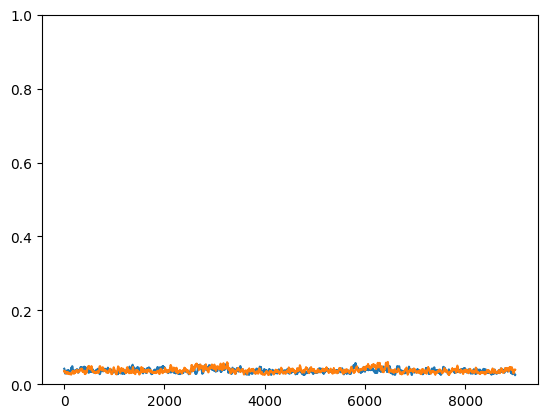

In [859]:
idx = 132
plt.plot(f1[idx])
plt.plot(f2[idx])
plt.ylim(0, 1)

In [868]:
f = day_1_random[5]['f']
m = np.argsort(np.argmax(f, axis=1))
f = f[m]

mask = f.max(axis=1) > 0.2
active = np.where(mask == True)[0]
inactive = np.where(mask == False)[0]
f_sort_day_1_random = np.zeros_like(f)
f_sort_day_1_random[:len(active)] = f[active]
f_sort_day_1_random[len(active):] = f[inactive]

f = day_2_random[5]['f']
f = f[m]
f_sort_day_2_random = np.zeros_like(f)
f_sort_day_2_random[:len(active)] = f[active]
f_sort_day_2_random[len(active):] = f[inactive]

f = day_1_reward[5]['f']
m = np.argsort(np.argmax(f, axis=1))
f = f[m]

mask = f.max(axis=1) > 0.2
active = np.where(mask == True)[0]
inactive = np.where(mask == False)[0]
f_sort_day_1_reward = np.zeros_like(f)
f_sort_day_1_reward[:len(active)] = f[active]
f_sort_day_1_reward[len(active):] = f[inactive]

f = day_2_reward[5]['f']
f = f[m]

f_sort_day_2_reward = np.zeros_like(f)
f_sort_day_2_reward[:len(active)] = f[active]
f_sort_day_2_reward[len(active):] = f[inactive]

In [861]:
9000 / 50

180.0

In [862]:
errs_day_1_random = []
errs_day_2_random = []
errs_day_1_reward = []
errs_day_2_reward = []

num_days = 10

for i in range(1, num_days):
    errs_day_1_random.append(((day_1_random[i]['behaviour'] - reward_2_stream) **2).mean())
    errs_day_2_random.append(((day_2_random[i]['behaviour'] - reward_2_stream) **2).mean())
    errs_day_1_reward.append(((day_1_reward[i]['behaviour'] - reward_2_stream) **2).mean())
    errs_day_2_reward.append(((day_2_reward[i]['behaviour'] - reward_2_stream) **2).mean())

In [879]:
mosaic = """
    AAAA
    BBCC
    XYZU
    """

colors = ['indianred', 'peru']
tiles = ['A', 'B', 'C']

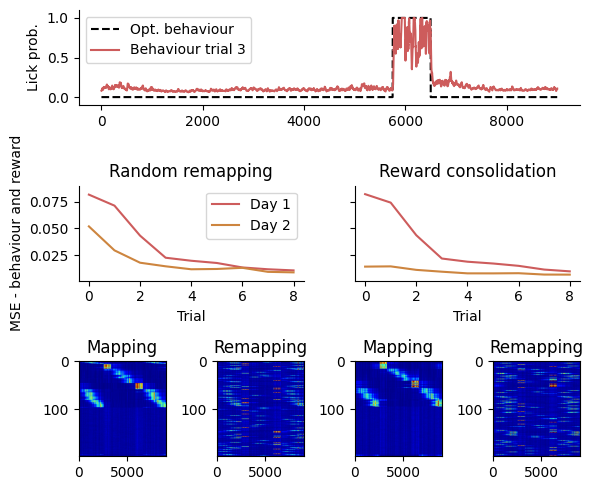

In [886]:
fig = plt.figure(figsize=(6,5))

ax_dict = fig.subplot_mosaic(mosaic)

for tile in tiles:
    ax_dict[tile].spines['top'].set_visible(False)
    ax_dict[tile].spines['right'].set_visible(False)

ax_dict['A'].set_ylabel('Lick prob.')

ax_dict['A'].set_ylim(-0.1, 1.1)
ax_dict['A'].plot(reward_2_stream, c='k', ls='--', label='Opt. behaviour')
ax_dict['A'].plot(day_1_random[5]['behaviour'], c=colors[0], label='Behaviour trial 3')
ax_dict['A'].legend()

ax_dict['B'].set_title('Random remapping')
ax_dict['B'].set_ylim(0.001, 0.09)
ax_dict['B'].set_ylabel('MSE - behaviour and reward')
ax_dict['B'].set_xlabel('Trial')


ax_dict['B'].plot(errs_day_1_random, label='Day 1', c=colors[0])
ax_dict['B'].plot(errs_day_2_random, label='Day 2', c=colors[1])

ax_dict['B'].legend()

ax_dict['C'].set_title('Reward consolidation')
ax_dict['C'].set_ylim(0.001, 0.09)
ax_dict['C'].set_xlabel('Trial')
ax_dict['C'].set_yticklabels([])
ax_dict['C'].plot(errs_day_1_reward, c=colors[0])
ax_dict['C'].plot(errs_day_2_reward, c=colors[1])

ax_dict['X'].set_title('Mapping')
ax_dict['X'].imshow(f_sort_day_1_random, aspect='auto', vmax=0.5, cmap='jet')
ax_dict['Y'].set_title('Remapping')
ax_dict['Y'].imshow(f_sort_day_2_random, aspect='auto', vmax=0.5, cmap='jet')
ax_dict['Z'].set_title('Mapping')
ax_dict['Z'].imshow(f_sort_day_1_reward, aspect='auto', vmax=0.5, cmap='jet')
ax_dict['U'].set_title('Remapping')
ax_dict['U'].imshow(f_sort_day_2_reward, aspect='auto', vmax=0.5, cmap='jet')

plt.tight_layout()
plt.savefig('fig5.png')

In [752]:
errs_day_1_random

[np.float64(0.07867382129719415),
 np.float64(0.04499532693211832),
 np.float64(0.023361537944808466),
 np.float64(0.01616765453763817),
 np.float64(0.015350308192621061),
 np.float64(0.011584825223757797),
 np.float64(0.010121206619963897),
 np.float64(0.0073802192842777874),
 np.float64(0.007491150872784529)]

In [853]:
f = day_1_reward[2]['f']
mask = f.max(axis=1) > 0.2

m = np.argsort(np.argmax(f, axis=1))
f = f[m]

mask = f.max(axis=1) > 0.2
active = np.where(mask == True)[0]
inactive = np.where(mask == False)[0]
f_sort = np.zeros_like(f)
f_sort[:len(active)] = f[active]
f_sort[len(active):] = f[inactive]



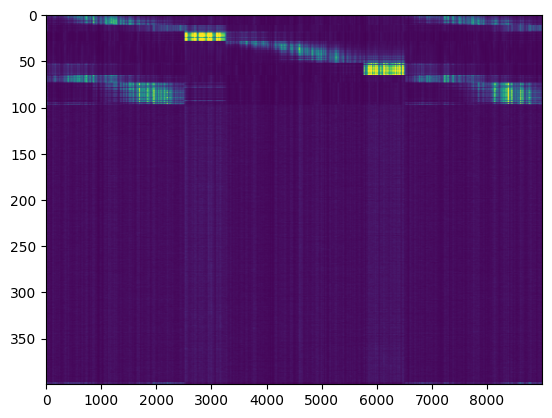

In [855]:
plt.imshow(f_sort, aspect='auto', vmax=0.5)

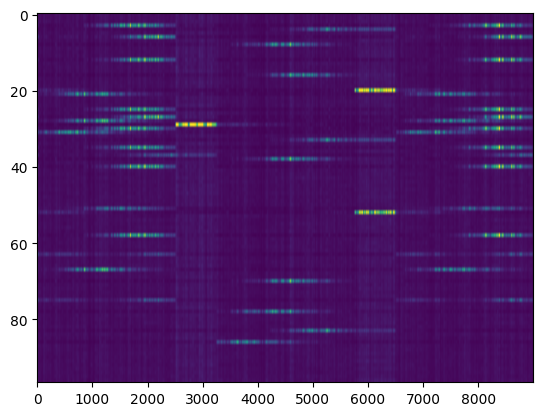

In [846]:
plt.imshow(f[m], vmax=0.5 ,aspect='auto')

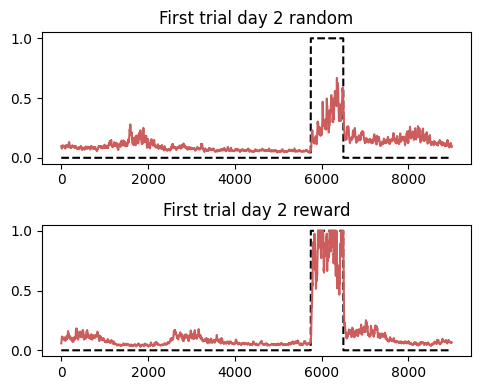

In [896]:
fig, ax = plt.subplots(nrows=2, figsize=(5, 4))

ax[0].set_title('First trial day 2 random')
ax[0].plot(reward_2_stream, c='k', ls='--', label='Opt. behaviour')
ax[0].plot(day_2_random[1]['behaviour'], c=colors[0], label='First ')

ax[1].set_title('First trial day 2 reward')
ax[1].plot(reward_2_stream, c='k', ls='--', label='Opt. behaviour')
ax[1].plot(day_2_reward[1]['behaviour'], c=colors[0], label='Behaviour trial 3')
plt.tight_layout()